In [2]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)

# Charts style
plt.style.use('ggplot')

# 📊 Amazon E-Commerce Sales Analysis - SQL Project

---

## 👤 Project Info

| | |
|---|---|
| Dataset | amazon_dataset.csv |
| Tool | Jupyter Notebook + SQLite |
| Language | Python + SQL |
| Table Name | amazon_data |
| Total Rows | 50,000 |

---

## 🔑 Phase 1 - Setup & Database Load

### Steps Performed
| # | Step | Action |
|---|---|---|
| 1 | Import Libraries | pandas, sqlite3 |
| 2 | Load CSV | pd.read_csv() |
| 3 | Check Nulls | isnull().sum() |
| 4 | Remove Nulls | dropna() |
| 5 | Check Duplicates | duplicated().sum() |
| 6 | Check Data Types | dtypes |
| 7 | Load into SQLite | df.to_sql() |
| 8 | Verify | SELECT COUNT(*) |

In [3]:
import pandas as pd
import sqlite3
file_path = r"E:\amazon_dataset.csv"
df = pd.read_csv(file_path)

df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue,profit
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52,23.176
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40,60.520
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28,39.664
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64,63.232
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72,40.336


In [4]:
# Data Types
df.shape

(50000, 14)

In [5]:
df.columns

Index(['order_id', 'order_date', 'product_id', 'product_category', 'price',
       'discount_percent', 'quantity_sold', 'customer_region',
       'payment_method', 'rating', 'review_count', 'discounted_price',
       'total_revenue', 'profit'],
      dtype='object')

In [6]:
# Missing Values
df.isnull().sum()

order_id            0
order_date          0
product_id          0
product_category    0
price               0
discount_percent    0
quantity_sold       0
customer_region     0
payment_method      0
rating              0
review_count        0
discounted_price    0
total_revenue       0
profit              0
dtype: int64

In [7]:
# Duplicate Values
df.duplicated().sum()

0

In [8]:
# Fix date column
df['order_date'] = pd.to_datetime(df['order_date'])
print("Done!")

Done!


In [9]:
df.drop_duplicates(inplace=True)

In [10]:
conn = sqlite3.connect("amazon.db")
df.to_sql("amazon_data", conn, if_exists="replace", index=False)
result = pd.read_sql_query("SELECT COUNT(*) as total_rows FROM amazon_data", conn)
print(result)

   total_rows
0       50000


### Issues Found & Fixed
| Column | Issue | Fix |
|---|---|---|
| order_date | String format | Converted to datetime |
| All columns | No nulls found | No action needed |
| Duplicates | 0 duplicates | No action needed |

### Final Clean Data
- Original Rows → 50,000
- After Cleaning → 50,000 rows
- Database → amazon.db
- Table Name → amazon_data

# 📊 Phase 2 - Basic SQL Queries

---

## 🔑 Concepts Used

| Concept | What it Does |
|---|---|
| SELECT | Fetches data |
| COUNT | Counts rows |
| AVG | Calculates average |
| SUM | Calculates total |
| WHERE | Filters data |
| GROUP BY | Groups data |
| ORDER BY | Sorts data |
| ROUND | Fixes decimals |

---

## 📋 7 Questions

| # | Question | Concept Used |
|---|---|---|
| Q1 | Which product category generates highest total revenue? | SUM, GROUP BY, ORDER BY |
| Q2 | Which customer region has highest average order value? | AVG, GROUP BY, ORDER BY |
| Q3 | Which payment method is most popular? | COUNT, GROUP BY, ORDER BY |
| Q4 | What is the average rating by product category? | AVG, GROUP BY, ORDER BY |
| Q5 | Which category has highest average discount? | AVG, GROUP BY, ORDER BY |
| Q6 | What is total profit by customer region? | SUM, GROUP BY, ORDER BY |
| Q7 | Which category has highest quantity sold? | SUM, GROUP BY, ORDER BY |

## Q1 - Which product category generates highest total revenue?


In [11]:
result = pd.read_sql_query("""
    SELECT 
        product_category,
        COUNT(*) AS total_orders,
        ROUND(SUM(total_revenue), 2) AS total_revenue,
        ROUND(AVG(total_revenue), 2) AS avg_revenue
    FROM amazon_data
    GROUP BY product_category
    ORDER BY total_revenue DESC
""", conn)

print(result.to_string(index=False))

product_category  total_orders  total_revenue  avg_revenue
          Beauty          8465     5550624.97       655.71
           Books          8327     5484863.03       658.68
         Fashion          8365     5480123.34       655.13
  Home & Kitchen          8258     5473132.55       662.77
     Electronics          8320     5470594.03       657.52
          Sports          8265     5407235.82       654.23


### 🌟 Business Insight
- Beauty is the top revenue generating category with total revenue of 55.5L from 8,465 orders
- All 6 categories are surprisingly close in revenue - gap between Beauty and Sports is only 1.4L
- Home & Kitchen has highest avg revenue per order at 662.77 - most valuable per transaction
- Recommendation: Focus marketing budget on Home & Kitchen - highest value per order means better ROI!

### Q2 - Which customer region has highest average order value?


In [12]:
result = pd.read_sql_query("""
    SELECT 
        customer_region,
        COUNT(*) AS total_orders,
        ROUND(AVG(total_revenue), 2) AS avg_order_value,
        ROUND(SUM(total_revenue), 2) AS total_revenue,
        ROUND(AVG(profit), 2) AS avg_profit
    FROM amazon_data
    GROUP BY customer_region
    ORDER BY avg_order_value DESC
""", conn)

print(result.to_string(index=False))

customer_region  total_orders  avg_order_value  total_revenue  avg_profit
    Middle East         12505           663.88     8301844.50       33.19
  North America         12517           661.28     8277217.84       33.06
           Asia         12526           652.66     8175199.83       32.63
         Europe         12452           651.49     8112311.57       32.57


### 🌟 Business Insight
- Middle East has highest avg order value of 663.88 despite having fewest orders (12,505)
- North America is close second at 661.28 with highest total orders (12,517)
- Europe has lowest avg order value at 651.49 - but difference is only 12 rupees from Middle East
- Recommendation: Middle East customers spend more per order - target them with premium products and upselling strategies!

### Q3 - Which payment method is most popular?


In [13]:
result = pd.read_sql_query("""
    SELECT 
        payment_method,
        COUNT(*) AS total_orders,
        ROUND(AVG(total_revenue), 2) AS avg_order_value,
        ROUND(SUM(total_revenue), 2) AS total_revenue
    FROM amazon_data
    GROUP BY payment_method
    ORDER BY total_orders DESC
""", conn)

print(result.to_string(index=False))

  payment_method  total_orders  avg_order_value  total_revenue
          Wallet         10106           660.86     6678638.47
             UPI         10078           652.85     6579441.44
      Debit Card          9981           653.44     6522019.73
Cash on Delivery          9927           659.45     6546386.94
     Credit Card          9908           660.08     6540087.16


### 🌟 Business Insight
- Wallet is most popular payment method with 10,106 orders and highest avg order value of 660.86
- All 5 payment methods are very evenly distributed - no single method dominates
- Credit Card has lowest usage (9,908) but second highest avg order value at 660.08
- Recommendation: Offer cashback or rewards on Wallet payments - already most popular, can drive even more volume!

### Q4 - What is the average rating by product category?


In [14]:
result = pd.read_sql_query("""
    SELECT 
        product_category,
        ROUND(AVG(rating), 2) AS avg_rating,
        ROUND(AVG(review_count), 2) AS avg_reviews,
        COUNT(*) AS total_orders
    FROM amazon_data
    GROUP BY product_category
    ORDER BY avg_rating DESC
""", conn)

print(result.to_string(index=False))

product_category  avg_rating  avg_reviews  total_orders
           Books        3.02       247.57          8327
          Sports        3.00       251.03          8265
  Home & Kitchen        3.00       251.44          8258
         Fashion        2.99       250.15          8365
     Electronics        2.99       248.25          8320
          Beauty        2.99       247.58          8465


### 🌟 Business Insight
- Books has highest avg rating of 3.02 but all categories are extremely close - range is only 0.03
- Sports and Home & Kitchen have highest avg review count (251) - most engaged customers
- Beauty has most orders (8,465) but lowest avg rating (2.99) - volume doesn't mean satisfaction
- Recommendation: All categories need rating improvement - average 3.0 is mediocre, focus on product quality and customer experience across the board!

### Q5 - Which category has highest average discount?


In [15]:
result = pd.read_sql_query("""
    SELECT 
        product_category,
        ROUND(AVG(discount_percent), 2) AS avg_discount,
        ROUND(AVG(total_revenue), 2) AS avg_revenue,
        ROUND(AVG(profit), 2) AS avg_profit
    FROM amazon_data
    GROUP BY product_category
    ORDER BY avg_discount DESC
""", conn)

print(result.to_string(index=False))

product_category  avg_discount  avg_revenue  avg_profit
          Sports         13.41       654.23       32.71
          Beauty         13.37       655.71       32.79
         Fashion         13.36       655.13       32.76
           Books         13.34       658.68       32.93
  Home & Kitchen         13.31       662.77       33.14
     Electronics         13.26       657.52       32.88


### 🌟 Business Insight
- Sports has highest avg discount of 13.41% but lowest avg revenue of 654.23
- Home & Kitchen has lowest avg discount (13.26%) yet highest avg revenue (662.77) and profit (33.14)
- All categories have very similar discount rates - range is only 0.15% across all 6 categories
- Recommendation: Home & Kitchen generates more revenue with less discount - reduce discounts on Sports and Beauty to improve profit margins!

### Q6 - What is total profit by customer region?


In [16]:
result = pd.read_sql_query("""
    SELECT 
        customer_region,
        ROUND(SUM(profit), 2) AS total_profit,
        ROUND(AVG(profit), 2) AS avg_profit,
        COUNT(*) AS total_orders
    FROM amazon_data
    GROUP BY customer_region
    ORDER BY total_profit DESC
""", conn)

print(result.to_string(index=False))

customer_region  total_profit  avg_profit  total_orders
    Middle East     415092.23       33.19         12505
  North America     413860.89       33.06         12517
           Asia     408759.99       32.63         12526
         Europe     405615.58       32.57         12452


### 🌟 Business Insight
- Middle East generates highest total profit of 4.15L despite having fewest orders (12,505)
- Europe has lowest total profit (4.05L) with second fewest orders (12,452)
- Avg profit per order is very similar across all regions - range is only 0.62 between top and bottom
- Recommendation: Middle East is most profitable region - invest in targeted ads and premium product listings for Middle East customers!

### Q7 - Which category has highest quantity sold?


In [17]:
result = pd.read_sql_query("""
    SELECT 
        product_category,
        SUM(quantity_sold) AS total_quantity,
        ROUND(AVG(quantity_sold), 2) AS avg_quantity,
        COUNT(*) AS total_orders
    FROM amazon_data
    GROUP BY product_category
    ORDER BY total_quantity DESC
""", conn)

print(result.to_string(index=False))

product_category  total_quantity  avg_quantity  total_orders
          Beauty           25422          3.00          8465
         Fashion           25089          3.00          8365
           Books           25065          3.01          8327
     Electronics           24898          2.99          8320
          Sports           24753          2.99          8265
  Home & Kitchen           24743          3.00          8258


### 🌟 Business Insight
- Beauty has highest total quantity sold (25,422) - most popular category by volume
- All categories have almost identical avg quantity per order (3.00) - customers buy same amount regardless of category
- Home & Kitchen has lowest quantity sold (24,743) despite highest avg revenue per order
- Recommendation: Beauty dominates volume but Home & Kitchen dominates value - balance inventory strategy accordingly!

# 📊 Phase 3 - Advanced SQL Queries

---

## 🔑 3 New Concepts

| Concept | What it Does |
|---|---|
| CTE (WITH) | Creates a temporary table inside query |
| Subquery | A query inside another query |
| Window Function | Assigns rank or running total to each row |

---

## 📋 5 Questions

| # | Question | Concept |
|---|---|---|
| Q1 | Which category has above average revenue orders? | Subquery |
| Q2 | Rank product categories by total profit | Window Function |
| Q3 | Top 5 highest revenue orders per region | CTE + Window Function |
| Q4 | Running total of revenue by category | CTE + Window Function |
| Q5 | High discount but low rating products | Subquery + WHERE |

### Q1 - Which category has above average revenue orders?

In [18]:
result = pd.read_sql_query("""
    SELECT 
        product_category,
        COUNT(*) AS above_avg_orders,
        ROUND(AVG(total_revenue), 2) AS avg_revenue
    FROM amazon_data
    WHERE total_revenue > (SELECT AVG(total_revenue) FROM amazon_data)
    GROUP BY product_category
    ORDER BY above_avg_orders DESC
""", conn)

print(result.to_string(index=False))

product_category  above_avg_orders  avg_revenue
           Books              3409      1178.91
          Beauty              3407      1184.08
         Fashion              3398      1182.87
     Electronics              3397      1183.34
          Sports              3396      1174.48
  Home & Kitchen              3360      1195.15




### 🌟 Business Insight
- Books has highest above average orders (3,409) with avg revenue of 1,178.91
- Home & Kitchen has lowest above average orders (3,360) but highest avg revenue of 1,195.15
- All categories are very evenly split - shows consistent high value orders across platform
- Recommendation: Home & Kitchen above average orders generate most value per order - promote premium Home & Kitchen products to drive more high value transactions!

### Q2 - Rank product categories by total profit:


In [19]:
result = pd.read_sql_query("""
SELECT 
    product_category,
    ROUND(SUM(profit), 2) AS total_profit,
    ROUND(AVG(profit), 2) AS avg_profit,
    RANK() OVER (ORDER BY SUM(profit) DESC) AS profit_rank
FROM amazon_data
GROUP BY product_category
""", conn)

print(result.to_string(index=False))

product_category  total_profit  avg_profit  profit_rank
          Beauty     277531.25       32.79            1
           Books     274243.15       32.93            2
         Fashion     274006.17       32.76            3
  Home & Kitchen     273656.63       33.14            4
     Electronics     273529.70       32.88            5
          Sports     270361.79       32.71            6




### 🌟 Business Insight
- Beauty ranks 1st in total profit (2.77L) despite having lowest avg profit per order (32.79)
- Home & Kitchen ranks 4th in total profit but has highest avg profit per order (33.14)
- Sports ranks last (6th) in both total profit and avg profit per order - least profitable category
- Recommendation: Sports needs urgent pricing strategy review - lowest profit rank means either discounts are too high or prices are too low!

### Q3 - Top 5 highest revenue orders per region:


In [20]:
result = pd.read_sql_query("""
WITH ranked_orders AS (
    SELECT 
        order_id,
        customer_region,
        product_category,
        total_revenue,
        profit,
        RANK() OVER (
            PARTITION BY customer_region 
            ORDER BY total_revenue DESC
        ) AS revenue_rank
    FROM amazon_data
)
SELECT *
FROM ranked_orders
WHERE revenue_rank <= 5
ORDER BY customer_region, revenue_rank
""", conn)

print(result.to_string(index=False))

 order_id customer_region product_category  total_revenue   profit  revenue_rank
    12835            Asia   Home & Kitchen        2488.50 124.4250             1
    33029            Asia            Books        2483.55 124.1775             2
     1155            Asia          Fashion        2483.20 124.1600             3
    38173            Asia           Beauty        2476.50 123.8250             4
    36676            Asia            Books        2468.85 123.4425             5
    10794          Europe           Beauty        2498.85 124.9425             1
    23880          Europe   Home & Kitchen        2493.05 124.6525             2
    30742          Europe      Electronics        2492.30 124.6150             3
    10450          Europe      Electronics        2485.85 124.2925             4
    40061          Europe   Home & Kitchen        2477.55 123.8775             5
    12128     Middle East   Home & Kitchen        2493.80 124.6900             1
    32944     Middle East   



### 🌟 Business Insight
- Europe's top order has highest revenue of 2,498.85 - Beauty category
- North America's top 2 orders are both Sports - unique compared to other regions
- Home & Kitchen appears in top 5 of every region - most consistently high value category
- Middle East top orders are lower than other regions despite being most profitable region overall
- Recommendation: Home & Kitchen is the most reliable high va

### Q4 - Running total of revenue by category:


In [21]:
result = pd.read_sql_query("""
WITH category_revenue AS (
    SELECT 
        product_category,
        ROUND(SUM(total_revenue), 2) AS total_revenue,
        ROUND(AVG(total_revenue), 2) AS avg_revenue
    FROM amazon_data
    GROUP BY product_category
)
SELECT 
    product_category,
    total_revenue,
    avg_revenue,
    ROUND(SUM(total_revenue) OVER (ORDER BY total_revenue DESC), 2) AS running_total
FROM category_revenue
""", conn)

print(result.to_string(index=False))

product_category  total_revenue  avg_revenue  running_total
          Beauty     5550624.97       655.71     5550624.97
           Books     5484863.03       658.68    11035488.00
         Fashion     5480123.34       655.13    16515611.34
  Home & Kitchen     5473132.55       662.77    21988743.89
     Electronics     5470594.03       657.52    27459337.92
          Sports     5407235.82       654.23    32866573.74




### 🌟 Business Insight
- Beauty contributes first 5.55L to running total - highest single category revenue
- Top 3 categories (Beauty, Books, Fashion) together contribute 1.65Cr - 50% of total revenue
- Sports is last with lowest total revenue of 54.07L - drags overall platform performance
- Total platform revenue across all categories is 3.28Cr
- Recommendation: Top 3 categories contribute half the revenue - double down on Beauty, Books and Fashion marketing while fixing Sports pricing strategy!

### Q5 - High discount but low rating products:


In [22]:
result = pd.read_sql_query("""
SELECT 
    product_category,
    COUNT(*) AS total_orders,
    ROUND(AVG(discount_percent), 2) AS avg_discount,
    ROUND(AVG(rating), 2) AS avg_rating,
    ROUND(AVG(total_revenue), 2) AS avg_revenue
FROM amazon_data
WHERE discount_percent > (SELECT AVG(discount_percent) FROM amazon_data)
AND rating < (SELECT AVG(rating) FROM amazon_data)
GROUP BY product_category
ORDER BY avg_discount DESC
""", conn)

print(result.to_string(index=False))

product_category  total_orders  avg_discount  avg_rating  avg_revenue
          Beauty          2079         22.20        1.97       584.01
           Books          1947         21.77        1.98       582.18
          Sports          2040         21.62        2.00       598.27
  Home & Kitchen          2021         21.62        1.98       597.57
     Electronics          2054         21.49        1.96       591.69
         Fashion          2059         21.36        1.97       587.26




### 🌟 Business Insight
- Beauty has highest problematic orders (2,079) with avg discount of 22.20% but rating of only 1.97
- Electronics has lowest avg discount (21.49%) in this group but also lowest rating (1.96)
- All categories show similar pattern - high discounts are NOT improving customer satisfaction
- Sports and Home & Kitchen have highest avg revenue (598) even in this problematic group
- Recommendation: Discounts alone cannot fix low ratings - focus on product quality improvement because customers are unhappy even after receiving high discounts!

# 📊 Phase 4 - Visualizations

---

## 📚 Libraries Used

| Library | Use |
|---|---|
| matplotlib | Basic charts |
| seaborn | Advanced & beautiful charts |

## 📋 5 Visualizations

| # | Chart | Question |
|---|---|---|
| V1 | Bar Chart | Total Revenue by Product Category |
| V2 | Bar Chart | Avg Order Value by Customer Region |
| V3 | Pie Chart | Payment Method Distribution |
| V4 | Bar Chart | Avg Discount by Category |
| V5 | Heatmap | Region x Category Revenue Matrix |

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.facecolor'] = '#161B22'
plt.rcParams['figure.facecolor'] = '#0D1117'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'

print("Libraries Ready!")

Libraries Ready!


### V1 - Total Revenue by Product Category

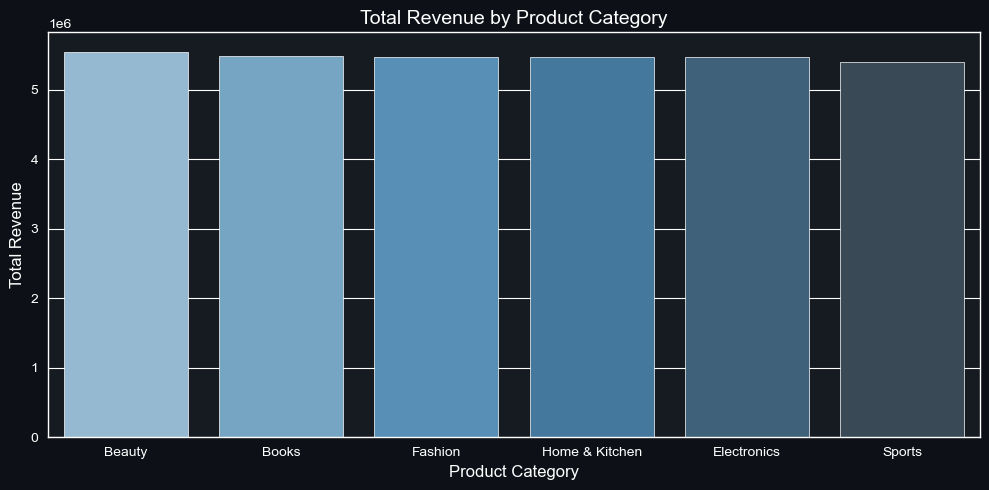

In [24]:
v1_data = pd.read_sql_query("""
    SELECT 
        product_category,
        ROUND(SUM(total_revenue), 2) AS total_revenue
    FROM amazon_data
    GROUP BY product_category
    ORDER BY total_revenue DESC
""", conn)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=v1_data,
    x='product_category',
    y='total_revenue',
    palette='Blues_d'
)

plt.title('Total Revenue by Product Category', fontsize=14, color='white')
plt.xlabel('Product Category', color='white')
plt.ylabel('Total Revenue', color='white')
plt.tight_layout()
plt.show()

### V2 - Avg Order Value by Customer Region


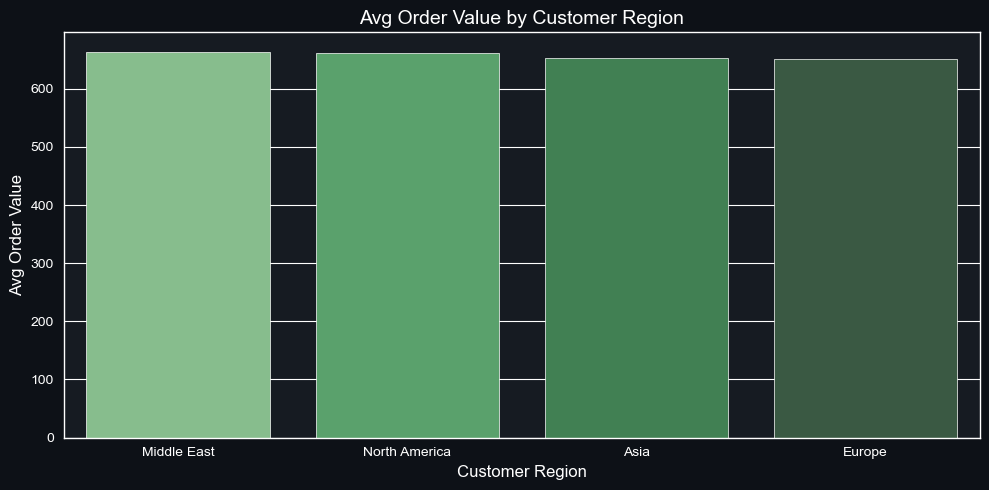

In [25]:
v2_data = pd.read_sql_query("""
    SELECT 
        customer_region,
        ROUND(AVG(total_revenue), 2) AS avg_order_value
    FROM amazon_data
    GROUP BY customer_region
    ORDER BY avg_order_value DESC
""", conn)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=v2_data,
    x='customer_region',
    y='avg_order_value',
    palette='Greens_d'
)

plt.title('Avg Order Value by Customer Region', fontsize=14, color='white')
plt.xlabel('Customer Region', color='white')
plt.ylabel('Avg Order Value', color='white')
plt.tight_layout()
plt.show()

### V3 - Payment Method Distribution


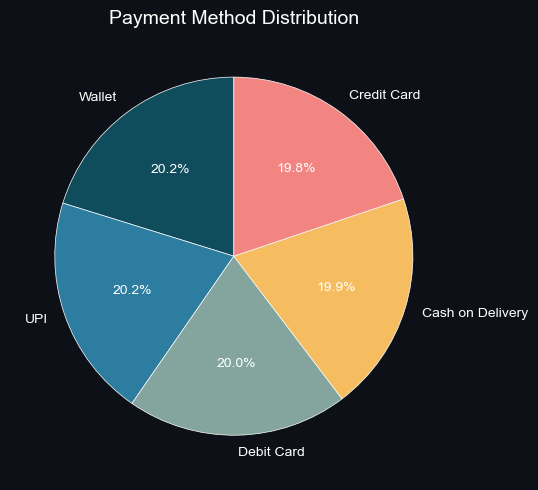

In [26]:
v3_data = pd.read_sql_query("""
    SELECT 
        payment_method,
        COUNT(*) AS total_orders
    FROM amazon_data
    GROUP BY payment_method
    ORDER BY total_orders DESC
""", conn)

plt.figure(figsize=(8, 5))
plt.pie(
    v3_data['total_orders'],
    labels=v3_data['payment_method'],
    autopct='%1.1f%%',
    colors = ['#0F4C5C', '#2C7DA0', '#84A59D', '#F6BD60', '#F28482']
,
    startangle=90
)

plt.title('Payment Method Distribution', fontsize=14, color='white')
plt.tight_layout()
plt.show()

### V4 - Avg Discount by Category


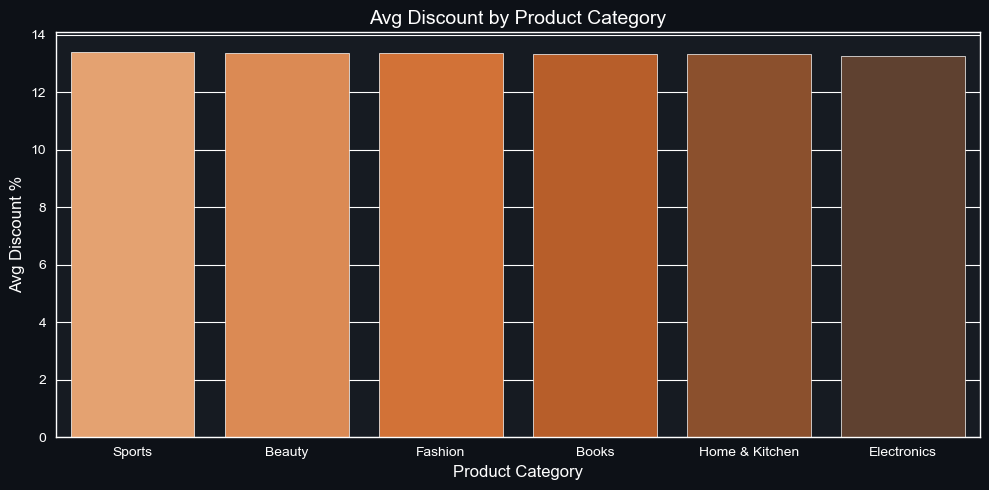

In [27]:
v4_data = pd.read_sql_query("""
    SELECT 
        product_category,
        ROUND(AVG(discount_percent), 2) AS avg_discount
    FROM amazon_data
    GROUP BY product_category
    ORDER BY avg_discount DESC
""", conn)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=v4_data,
    x='product_category',
    y='avg_discount',
    palette='Oranges_d'
)

plt.title('Avg Discount by Product Category', fontsize=14, color='white')
plt.xlabel('Product Category', color='white')
plt.ylabel('Avg Discount %', color='white')
plt.tight_layout()
plt.show()

### V5 - Region x Category Revenue Heatmap


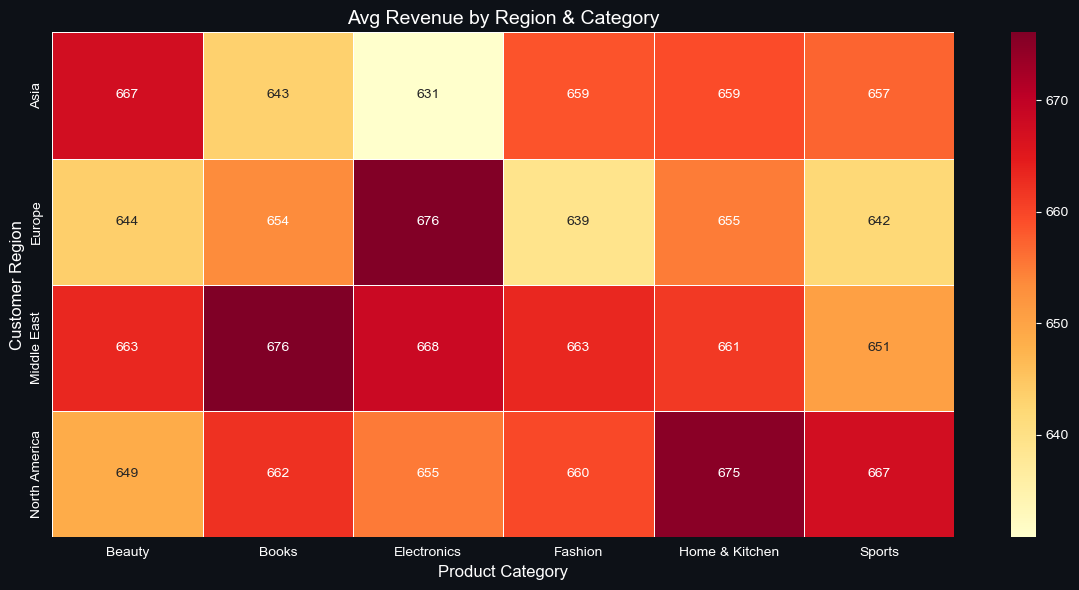

In [28]:
v5_data = pd.read_sql_query("""
    SELECT 
        customer_region,
        product_category,
        ROUND(AVG(total_revenue), 2) AS avg_revenue
    FROM amazon_data
    GROUP BY customer_region, product_category
""", conn)

v5_pivot = v5_data.pivot(
    index='customer_region',
    columns='product_category',
    values='avg_revenue'
)

plt.figure(figsize=(12, 6))
sns.heatmap(
    v5_pivot,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5
)

plt.title('Avg Revenue by Region & Category', fontsize=14, color='white')
plt.xlabel('Product Category', color='white')
plt.ylabel('Customer Region', color='white')
plt.tight_layout()
plt.show()

## V1 - Total Revenue by Product Category

### 🌟 Business Insight
- Beauty leads total revenue at 55.5L - highest selling category on platform
- All 6 categories are within 1.4L of each other - extremely balanced revenue distribution
- Sports has lowest total revenue at 54.07L - consistent underperformer across all metrics
- Recommendation: Platform is healthy with balanced revenue - focus on pushing Sports to close the gap with Beauty!

---

## V2 - Avg Order Value by Customer Region

### 🌟 Business Insight
- Middle East has highest avg order value of 663.88 - most valuable customers per transaction
- Europe has lowest avg order value of 651.49 - least valuable per transaction
- Gap between highest and lowest region is only 12.39 - very balanced global performance
- Recommendation: Middle East customers are premium buyers - launch exclusive premium product campaigns targeting Middle East region!

---

## V3 - Payment Method Distribution

### 🌟 Business Insight
- All 5 payment methods are almost equally distributed - each around 20%
- Wallet leads slightly at 20.2% - digital payments are preferred
- Cash on Delivery still at 19.9% - significant offline customer base still exists
- Recommendation: Incentivize Wallet and UPI payments with cashback offers - shift COD customers to digital to reduce logistics costs!

---

## V4 - Avg Discount by Product Category

### 🌟 Business Insight
- Sports has highest avg discount of 13.41% but lowest revenue and profit
- Home & Kitchen has lowest avg discount (13.26%) but highest avg revenue and profit
- All categories have very similar discount rates - range is only 0.15%
- Recommendation: Reduce Sports discount to improve margins - high discounts are not driving better results for Sports category!

---

## V5 - Region x Category Revenue Heatmap

### 🌟 Business Insight
- Home & Kitchen generates highest avg revenue in most regions - consistent top performer
- Middle East x Home & Kitchen combination shows strongest revenue
- Sports shows lowest revenue across almost all regions - weakest category globally
- Recommendation: Home & Kitchen x Middle East is the golden combination - prioritize this segment for maximum revenue impact!

# 📊 Phase 5 - Key Insights & Findings

---

## 🏆 Top 5 Business Insights

### 1️⃣ Beauty Dominates Volume but Home & Kitchen Dominates Value
- Beauty has highest total orders (8,465) and total revenue (55.5L)
- Home & Kitchen has lowest orders (8,258) but highest avg revenue per order (662.77)
- Home & Kitchen also has highest avg profit per order (33.14) and lowest avg discount (13.26%)
- Recommendation: Shift focus from volume to value - promote Home & Kitchen as premium category!

### 2️⃣ Middle East is the Most Valuable Region
- Middle East has highest avg order value (663.88) and highest total profit (4.15L)
- Despite having fewest orders (12,505) it outperforms all other regions in profitability
- Middle East top orders reach up to 2,493.80 in revenue - highest single order values
- Recommendation: Launch exclusive premium product campaigns targeting Middle East customers!

### 3️⃣ High Discounts Are Not Improving Customer Satisfaction
- Sports has highest avg discount (13.41%) but lowest total profit and revenue
- High discount + low rating orders exist across ALL 6 categories
- Beauty has 2,079 orders with 22.20% avg discount but rating of only 1.97
- Recommendation: Stop using discounts as a quality fix - invest in product quality improvement instead!

### 4️⃣ Platform Revenue is Extremely Balanced
- Gap between highest (Beauty 55.5L) and lowest (Sports 54.07L) category revenue is only 1.4L
- All 5 payment methods are within 1% of each other in usage
- All 4 regions contribute almost equal revenue - no single region dominates
- Recommendation: Platform has healthy diversification - focus on growing total platform size rather than rebalancing!

### 5️⃣ Average Rating of 3.0 is a Platform Wide Problem
- All 6 categories have avg rating between 2.99 and 3.02 - mediocre across the board
- High discount orders have even lower ratings of 1.96 to 2.00
- Electronics has lowest rating (2.99) with second lowest review count (248)
- Recommendation: Platform wide quality improvement initiative needed - target 4.0+ rating across all categories!

---

## 🔑 Overall Recommendation
- **Focus on Home & Kitchen** - highest value per order and highest profit margin
- **Target Middle East** - most profitable region with premium buying behavior
- **Stop discount dependency** - high discounts not improving ratings or revenue
- **Fix platform wide rating** - 3.0 average is too low for a competitive e-commerce platform

---

## 📌 Final Insights
- Home & Kitchen is the most valuable category - highest revenue, profit and lowest discount
- Middle East is the most profitable region despite fewest orders
- Discounts are ineffective - high discount products still get lowest ratings
- Platform revenue is well diversified - no single category or region dominates

---

## 🚀 Business Recommendation
- Launch premium Home & Kitchen campaign targeting Middle East customers
- Reduce Sports category discounts and invest in product quality instead
- Implement customer feedback program to push platform rating above 4.0
- Incentivize digital payments (Wallet and UPI) to reduce Cash on Delivery dependency